In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

In [3]:
df = pd.read_csv('/content/UPSC_Final_Dataset.csv')

In [4]:
df.head()

,Candidate_ID,Gender,Category,Educational_Background,Optional_Subject,Attempt_Number,Average_Daily_Study_Hours,Joined_Test_Series,Past_Mains_Written_Count,Prelims_GS_Score,...,GS_Paper_3,GS_Paper_4,Optional_1,Optional_2,Total_Mains,Interview_Call,Interview_Marks,Final_Total,Final_Rank,Service_Allocated
0,UPSC2026-000000,Female,Scheduled Castes (SC),Engineering,Sociology,1,6.919113,Yes,0,77.22,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,Not Recommended
1,UPSC2026-000001,Male,General,Science,Public Administration,3,7.881640,Yes,2,90.96,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,Not Recommended
2,UPSC2026-000002,Female,Economically Weaker Sections (EWS),Medical,Sociology,4,10.552436,Yes,3,87.56,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,Not Recommended
3,UPSC2026-000003,Male,Economically Weaker Sections (EWS),Engineering,Public Administration,2,6.153433,Yes,0,112.79,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,Not Recommended
4,UPSC2026-000004,Male,Scheduled Tribes (ST),Humanities,Public Administration,6,7.748108,Yes,5,126.79,...,102.6,153.9,110.5,131.5,819.0,False,NaN,819.0,NaN,Not Recommended


In [7]:
df.isnull().sum()

,0
Candidate_ID,0
Gender,0
Category,0
Educational_Background,0
Optional_Subject,0
Attempt_Number,0
Average_Daily_Study_Hours,0
Joined_Test_Series,0
Past_Mains_Written_Count,0
Prelims_GS_Score,0


In [9]:
df = df.fillna(0)

In [12]:
df.head()

,Candidate_ID,Gender,Category,Educational_Background,Optional_Subject,Attempt_Number,Average_Daily_Study_Hours,Joined_Test_Series,Past_Mains_Written_Count,Prelims_GS_Score,...,GS_Paper_3,GS_Paper_4,Optional_1,Optional_2,Total_Mains,Interview_Call,Interview_Marks,Final_Total,Final_Rank,Service_Allocated
0,UPSC2026-000000,Female,Scheduled Castes (SC),Engineering,Sociology,1,6.919113,Yes,0,77.22,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended
1,UPSC2026-000001,Male,General,Science,Public Administration,3,7.881640,Yes,2,90.96,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended
2,UPSC2026-000002,Female,Economically Weaker Sections (EWS),Medical,Sociology,4,10.552436,Yes,3,87.56,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended
3,UPSC2026-000003,Male,Economically Weaker Sections (EWS),Engineering,Public Administration,2,6.153433,Yes,0,112.79,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended
4,UPSC2026-000004,Male,Scheduled Tribes (ST),Humanities,Public Administration,6,7.748108,Yes,5,126.79,...,102.6,153.9,110.5,131.5,819.0,False,0.0,819.0,0.0,Not Recommended


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Candidate_ID               100000 non-null  object 
 1   Gender                     100000 non-null  object 
 2   Category                   100000 non-null  object 
 3   Educational_Background     100000 non-null  object 
 4   Optional_Subject           100000 non-null  object 
 5   Attempt_Number             100000 non-null  int64  
 6   Average_Daily_Study_Hours  100000 non-null  float64
 7   Joined_Test_Series         100000 non-null  object 
 8   Past_Mains_Written_Count   100000 non-null  int64  
 9   Prelims_GS_Score           100000 non-null  float64
 10  CSAT_Score                 100000 non-null  float64
 11  Passed_Prelims             100000 non-null  bool   
 12  Mains_Essay                100000 non-null  float64
 13  GS_Paper_1                 100

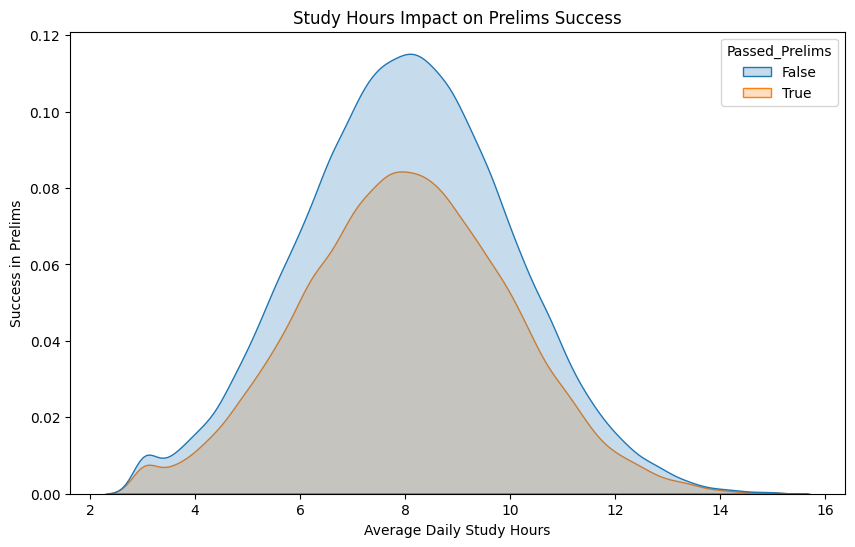

In [10]:
plt.figure(figsize = (10,6))
sns.kdeplot(data = df, x = 'Average_Daily_Study_Hours', hue = 'Passed_Prelims', fill = True)
plt.title('Study Hours Impact on Prelims Success')
plt.xlabel('Average Daily Study Hours')
plt.ylabel('Success in Prelims')
plt.show()

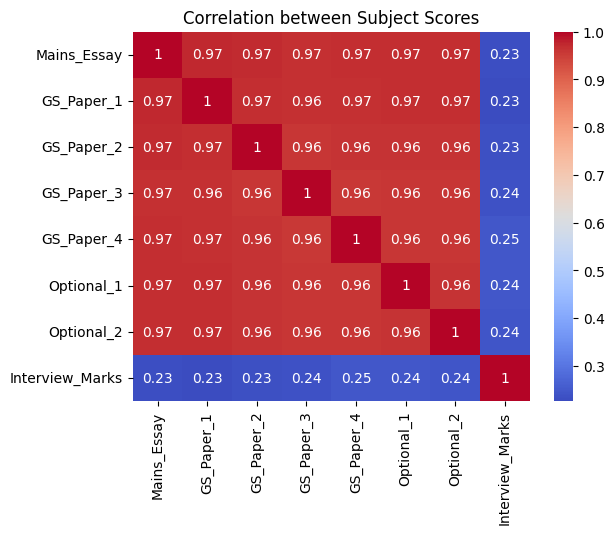

In [11]:
mains_papers = ['Mains_Essay', 'GS_Paper_1', 'GS_Paper_2', 'GS_Paper_3', 'GS_Paper_4', 'Optional_1', 'Optional_2', 'Interview_Marks']
corr = df[mains_papers].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Subject Scores')
plt.savefig('correlation_heatmap.png')

In [14]:
le = LabelEncoder()
df['BG_Encoded'] = le.fit_transform(df['Educational_Background'])

In [15]:
X = df[['Attempt_Number', 'Average_Daily_Study_Hours', 'Prelims_GS_Score', 'CSAT_Score', 'BG_Encoded']]
y = df['Passed_Prelims']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Prelims_GS_Score             0.834272
CSAT_Score                   0.153324
Attempt_Number               0.011845
Average_Daily_Study_Hours    0.000477
BG_Encoded                   0.000082
dtype: float64


In [19]:
df.head()

,Candidate_ID,Gender,Category,Educational_Background,Optional_Subject,Attempt_Number,Average_Daily_Study_Hours,Joined_Test_Series,Past_Mains_Written_Count,Prelims_GS_Score,...,GS_Paper_4,Optional_1,Optional_2,Total_Mains,Interview_Call,Interview_Marks,Final_Total,Final_Rank,Service_Allocated,BG_Encoded
0,UPSC2026-000000,Female,Scheduled Castes (SC),Engineering,Sociology,1,6.919113,Yes,0,77.22,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended,1
1,UPSC2026-000001,Male,General,Science,Public Administration,3,7.881640,Yes,2,90.96,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended,4
2,UPSC2026-000002,Female,Economically Weaker Sections (EWS),Medical,Sociology,4,10.552436,Yes,3,87.56,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended,3
3,UPSC2026-000003,Male,Economically Weaker Sections (EWS),Engineering,Public Administration,2,6.153433,Yes,0,112.79,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,Not Recommended,1
4,UPSC2026-000004,Male,Scheduled Tribes (ST),Humanities,Public Administration,6,7.748108,Yes,5,126.79,...,153.9,110.5,131.5,819.0,False,0.0,819.0,0.0,Not Recommended,2
